In [1]:
import os, random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import torch
import torch.nn as nn
from pathlib import PureWindowsPath
import torchvision.models as models
from matplotlib.patches import Patch
from monai.transforms import LoadImage
from monai.data import Dataset, DataLoader
from monai.transforms import (
    Compose,
    LoadImaged,
    EnsureChannelFirstd,
    ScaleIntensityd,
    Resized
)

from monai.networks.nets import resnet18

import sys
sys.path.append("/projects/net_contrast_classification/contrast_phase")
from Radiomics.radiomics_pipeline import list_organs, multi_channel


In [2]:
data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/data/cleaned_data_1.csv")
folder_path = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET"
# train_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/preprocessed_data/train.csv")
# test_data = pd.read_csv("/projects/net_contrast_classification/contrast_phase/preprocessed_data/test.csv")

# train_pca = pd.read_csv("/projects/net_contrast_classification/contrast_phase/preprocessed_data/train_pca.csv")
# test_pca = pd.read_csv("/projects/net_contrast_classification/contrast_phase/preprocessed_data/test_pca.csv")

## 3D Classification Model

### Selecting only the relevant organs

In [3]:
data = data[(data.contrast.isin(['Arterial', "Portal"])) 
            & (data.exist_on_server.notna())
            & (data.is_liver_imaged == "Yes")
            & (data.phase_timing != '0.0')]
data.contrast.value_counts()

contrast
Portal      3153
Arterial    1996
Name: count, dtype: int64

In [4]:
data.phase_timing.value_counts()

phase_timing
Just Right    4321
Too Early      689
Too Late       139
Name: count, dtype: int64

In [5]:
data['contrast_timing'] = (data["contrast"].str.cat(data["phase_timing"], sep=" "))
data["contrast_timing"] = data["contrast_timing"].astype(str).str.strip()

In [6]:
data.contrast_timing.value_counts()

contrast_timing
Portal Just Right      3015
Arterial Just Right    1306
Arterial Too Early      598
Arterial Too Late        92
Portal Too Early         91
Portal Too Late          47
Name: count, dtype: int64

In [7]:
sampled_df = data.groupby('contrast_timing', group_keys=False).apply(lambda x: x.sample(n=min(len(x), 25), random_state=42))
sampled_df['contrast_timing'] = (sampled_df["contrast"].str.cat(sampled_df["phase_timing"], sep=" "))
sampled_df["contrast_timing"] = sampled_df["contrast_timing"].astype(str).str.strip()

In [8]:
sampled_df.contrast_timing.value_counts()

contrast_timing
Arterial Just Right    25
Arterial Too Early     25
Arterial Too Late      25
Portal Just Right      25
Portal Too Early       25
Portal Too Late        25
Name: count, dtype: int64

In [9]:
files = [os.path.join(folder_path, PureWindowsPath(f).name) for f in sampled_df["MatchKey"]]
files[0]

'/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0777_20230308_kalina99_5191.nii.gz'

In [10]:
organ_files = []
for file in files:

    organ_file = os.path.basename(file).replace(".nii.gz", ".organs.nii.gz")
    organ_file = os.path.join(folder_path, PureWindowsPath(organ_file).name)

    organ_files.append(organ_file)

organ_files[0]

'/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/NKI-d23231-00-0777_20230308_kalina99_5191.organs.nii.gz'

In [ ]:
organ_ids, organ_names = list_organs(selected = [1,2,3,5,8,9,13,51,52,63,64,65,66],
                                     by = "id")


loader = LoadImage(image_only=True, ensure_channel_first=True)
image_array = loader(files[0])
organ_array_single = loader(organ_files[0])
organ_array = multi_channel(organ_ids, organ_array_single)

print("CT image array shape:", image_array.shape)
print("Single-channel organ array shape:", organ_array_single.shape)
print("Multi-organ array shape:", organ_array.shape)


CT image array shape: torch.Size([1, 512, 512, 152])
Single-channel organ array shape: torch.Size([1, 512, 512, 152])
Multi-organ array shape: (13, 512, 512, 152)


In [12]:
def window_ct(img, center=50, width=150):
    low = center - width / 2
    high = center + width / 2
    return img.clip(low, high)

ORGANS = dict(zip(organ_ids, organ_names))
ORGANS

{1: 'spleen',
 2: 'kidney_right',
 3: 'kidney_left',
 5: 'liver',
 8: 'adrenal_gland_right',
 9: 'adrenal_gland_left',
 13: 'small_bowel',
 51: 'heart',
 52: 'aorta',
 63: 'inferior_vena_cava',
 64: 'portal_vein_and_splenic_vein',
 65: 'iliac_artery_left',
 66: 'iliac_artery_right'}

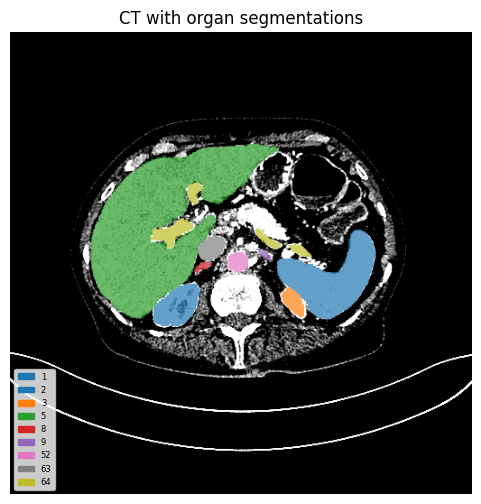

In [13]:
slice = 120
plt.figure(figsize=(6,6))
plt.imshow(window_ct(np.rot90(image_array[0, :, :, slice], k=1)), cmap="gray")

colors = plt.get_cmap("tab10", len(ORGANS))
legend_patches = []

organ_names = list(ORGANS.keys())

for i, organ_name in enumerate(organ_names):
    mask = organ_array[i, :, :, slice]

    if mask.sum() == 0:
        continue

    color = colors(i)
    rgba = np.zeros((*mask.shape, 4))
    rgba[..., :3] = color[:3]
    rgba[..., 3] = mask * 0.7  # transparency only where mask==1

    plt.imshow(np.rot90(rgba, k=1))

    legend_patches.append(
        Patch(color=color[:3], label=organ_name)
    )

plt.legend(
    handles=legend_patches,
    loc="lower left",
    framealpha=0.8,
    fontsize=6
)

plt.title("CT with organ segmentations")
plt.axis("off")
plt.show()

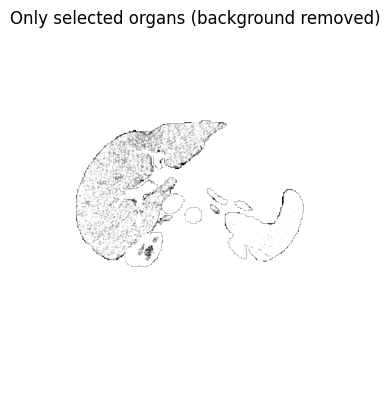

In [ ]:
# Remove channel dims
ct = image_array.squeeze(0)              # [H, W, D]
organ_array_single.squeeze(0)     # [H, W, D]
combined_mask = (organ_array > 0).any(axis=0) # if voxel belongs to any organ (1st dimension = 0) => True, else False

# Apply mask

slice_ct = ct[:, :, slice]
slice_mask = combined_mask[:, :, slice]


masked_slice = np.where(
    (slice_mask > 0) & (slice_mask < 300), # Remove background and restrict to soft tissue 
    slice_ct,
    np.nan
)

# Plot
plt.imshow(np.rot90(window_ct(masked_slice), k=1), cmap="gray")
plt.title("Only selected organs (background removed)")
plt.axis("off")
plt.show()

In [8]:
print(image_array.shape, organ_array.shape)

torch.Size([1, 512, 512, 150]) (13, 512, 512, 150)


In [ ]:
import torch.nn.functional as F

def keep_organ_volume(image_array, organ_array):
    mask = torch.tensor((organ_array > 0).any(axis=0), device=image_array.device)

    coords = mask.nonzero()

    h_min, w_min, d_min = coords.min(dim=0).values
    h_max, w_max, d_max = coords.max(dim=0).values

    ct_cropped = image_array[
        :,
        h_min:h_max+1,
        w_min:w_max+1,
        d_min:d_max+1
    ]

    mask_cropped = mask[h_min:h_max+1, w_min:w_max+1, d_min:d_max+1]

    ct_cropped[:, ~mask_cropped] = -1024

    return ct_cropped

def pad_to_shape(x, target_shape):
    """
    Pads a 3D image (C, H, W, D) to target_shape, centering the image in the padded volume.
    Pads with -1024 (air in CT).
    """
    _, H, W, D = x.shape
    _, Ht, Wt, Dt = target_shape

    pad_H = Ht - H
    pad_W = Wt - W
    pad_D = Dt - D

    # compute padding before and after for each dimension
    pad_H_before = pad_H // 2
    pad_H_after = pad_H - pad_H_before

    pad_W_before = pad_W // 2
    pad_W_after = pad_W - pad_W_before

    pad_D_before = pad_D // 2
    pad_D_after = pad_D - pad_D_before

    # F.pad expects padding in reverse order: (D, W, H)
    pad = (pad_D_before, pad_D_after,
           pad_W_before, pad_W_after,
           pad_H_before, pad_H_after)

    return F.pad(x, pad, value=-1024)  # use -1024 pading value because air ~ -1024 HU

In [ ]:
ct_cropped = keep_organ_volume(image_array, organ_array)
ct_cropped.shape

torch.Size([1, 317, 208, 120])

In [26]:
ct_padded = pad_to_shape(ct_cropped, [1,400, 400, 150])
ct_padded.shape

torch.Size([1, 400, 400, 150])

(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

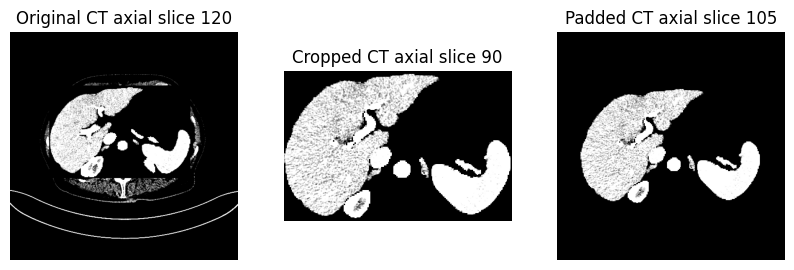

In [40]:
slice = 120
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.imshow(np.rot90(window_ct(image_array[0][:, :, slice]), k=1), cmap="gray") 
plt.title(f"Original CT axial slice {slice}") 
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(np.rot90(window_ct(ct_cropped[0][:, :, (slice-30)]), k=1), cmap="gray") # 30 slices are 'lost' in the cropping
plt.title(f"Cropped CT axial slice {(slice-30)}")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(np.rot90(window_ct(ct_padded[0][:, :, (slice-15)]), k=1), cmap="gray") # 30/2 slices are added on each side after padding
plt.title(f"Padded CT axial slice {(slice-15)}")
plt.axis("off")

### CNN Model

In [55]:
def create_dataset(image_files, organ_files):
    loader = LoadImage(image_only=True, ensure_channel_first=True)
    cropped_images = []
    shapes = []
    for file, organ_file in zip(image_files, organ_files):
    
        image_array = loader(file)
        organ_array_single = loader(organ_file)
        organ_array = multi_channel(organ_ids, organ_array_single)
        ct_cropped = keep_organ_volume(image_array, organ_array)
        cropped_images.append(ct_cropped)
        shapes.append(ct_cropped.shape)

    # Compute mean shape of cropped images
    mean_shape = np.round(np.array(shapes).mean(axis=0)).astype(int).tolist()  # shape: (n_samples, 4) assuming (C,H,W,D)
    print("Mean shape of cropped CT images:", mean_shape)


    dataset = []
    for image in cropped_images:
        ct_padded = pad_to_shape(image, mean_shape)
        dataset.append(ct_padded)

    return dataset

In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
dataset_list = create_dataset(files, organ_files)
labels = le.fit_transform(sampled_df.contrast_timing)

dataset_dicts = [
    {"image": img, "label": label} 
    for img, label in zip(dataset_list, labels)
]

transforms = Compose([
    EnsureChannelFirstd(keys=["image"]),
    ScaleIntensityd(keys=["image"])
])


dataset = Dataset(data=dataset_dicts, transform=transforms)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

model = resnet18(
    spatial_dims=3,
    n_input_channels=1,
    num_classes=6
)

: 

In [68]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

In [ ]:
# batch = next(iter(loader))
# print(batch["image"].shape)
# print(batch["label"])

torch.Size([2, 1, 128, 128, 128])
tensor([1, 1])


In [ ]:
# import os

# folder = "/mnt/rhea/data_private/IRBd23-231/GEPNETs/ARTINET/not_on_server"

# dataset_list = [
#     {
#         "image": os.path.join(folder, row.MatchKey),
#         "label": row.contrast
#     }
#     for _, row in selected_data.iterrows()
#     if os.path.exists(os.path.join(folder, row.MatchKey))
# ]

# print(f"{len(dataset_list)} files found for training")

100 files found for training


In [71]:

loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(10):
    
    model.train()
    epoch_loss = 0
    
    for batch in loader:
        
        images = batch["image"].to(device)
        labels = batch["label"].to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    print(f"Epoch {epoch+1}, loss: {epoch_loss/len(loader):.4f}")

# # replace classification head
# model.fc = nn.Sequential(
#     nn.Linear(model.fc.in_features, 128),
#     nn.ReLU(),
#     nn.Linear(128, 6)
# )


: 

# Classification + Sequence Modelling

In [4]:
data.AcquisitionTime_sec

0       40231.70000
1       30853.90000
2       32599.60000
3       45013.30692
4       51587.10418
           ...     
8729    54796.11932
8730    43545.56100
8731    43580.13800
8732    42200.65000
8733    42230.04200
Name: AcquisitionTime_sec, Length: 8734, dtype: float64